In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set()

# CSVを読み込む
df = pd.read_csv('../data/0_KL/1_ShadowHand_SAPG_s4_KL.csv')
#df = pd.read_csv('../data/0_KL/1_ShadowHand_CPOwoAdR_s4_KL.csv')
#df = pd.read_csv('../data/0_KL/1_ShadowHand_CPOwAdR_s4_KL.csv')

#df = pd.read_csv('../data/0_KL/2_AllegroHand_SAPG_s4_KL.csv')
#df = pd.read_csv('../data/0_KL/1_AllegroHand_CPOwoAdR_s4_KL.csv')


print(len(df)) # 全部で52000になる

/home/mil/shitanda/.pyenv/versions/anaconda3-2023.03/envs/sapg2/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


104000


target_envstep 15000000000
target_epoch 76293
tensor([[-0.0040,  0.1149,  0.0215,  0.0333,  0.0791,  0.0638],
        [ 0.1071, -0.0044,  0.1314,  0.1562,  0.2499,  0.2418],
        [ 0.0213,  0.1403, -0.0041,  0.0756,  0.1348,  0.1048],
        [ 0.0336,  0.1702,  0.0773, -0.0040,  0.1291,  0.0823],
        [ 0.0834,  0.2829,  0.1444,  0.1353, -0.0038,  0.0857],
        [ 0.0677,  0.2757,  0.1132,  0.0870,  0.0868, -0.0037]])


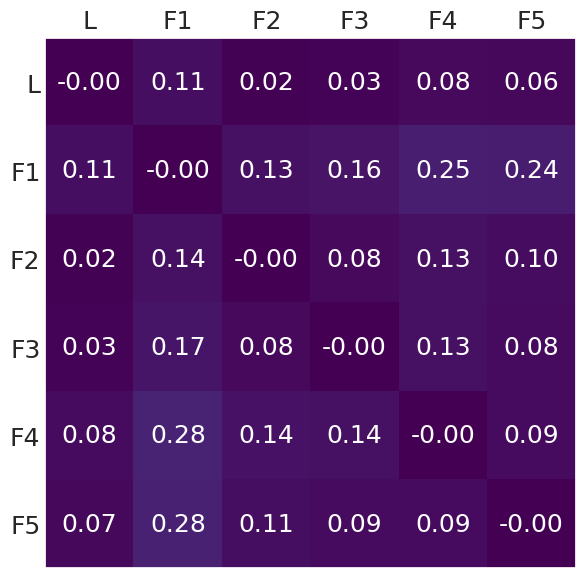

In [24]:

target_envstep = 15 * 10**9
horizon_length = 8
num_envs = 24576

target_epoch = int(target_envstep / (horizon_length * num_envs))
print("target_envstep", target_envstep)
print("target_epoch", target_epoch)

#target_epoch = 50000



row = df.iloc[target_epoch]  # 1行目だけ取り出す (Series)
# numpy配列にしてからtensor化
tensor = torch.tensor(row.values, dtype=torch.float32).view(6, 6)
tensor = torch.flip(tensor.flatten(), dims=[0]).view(6, 6)


print(tensor)


# ラベルとダミー tensor（適宜置き換えてください）
labels = ["L", "F1", "F2", "F3", "F4", "F5"]


fig, ax = plt.subplots(figsize=(6, 6))

# imshow で値を表示
im = ax.imshow(tensor.numpy(), cmap='viridis', vmin=0, vmax=3)

# 主目盛（ラベル用）
ax.set_xticks(np.arange(6))
ax.set_yticks(np.arange(6))

ax.set_xticklabels(labels, fontsize=18)
ax.set_yticklabels(labels, fontsize=18)

ax.xaxis.set_ticks_position('top')      # 目盛り（数字）を上側に
ax.xaxis.set_label_position('top')      # 軸ラベル（Xの名前など）がある場合の位置

# グリッド線をセルの境界に描画するためのマイナー目盛


#ax.grid(which='minor', color='white', linestyle='-', linewidth=0)
ax.grid(False)

# 主目盛の線は消して、すっきりさせる
ax.tick_params(which='major', length=0)

# 各セルに値を白で表示
for i in range(6):
    for j in range(6):
        val = tensor[i, j].item()
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white', fontsize=18)


# タイトル（任意）
#ax.set_title("Epoch 0 / 0")

# カラーバーとレイアウト調整
#fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# svgに出力
fig.savefig("kl.svg", format="svg", bbox_inches='tight', pad_inches=0.1)